In [1]:
#!pip install --upgrade pip
#!pip install scikit-learn
#!pip install tensorflow
#!pip install matplotlib
#!pip install pandas
#!pip install numpy
#!pip install seaborn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras
from keras.callbacks import EarlyStopping



In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

print(df.shape)
print(df.head(10))


(45211, 17)
   age           job   marital  education default  balance housing loan  \
0   58    management   married   tertiary      no     2143     yes   no   
1   44    technician    single  secondary      no       29     yes   no   
2   33  entrepreneur   married  secondary      no        2     yes  yes   
3   47   blue-collar   married    unknown      no     1506     yes   no   
4   33       unknown    single    unknown      no        1      no   no   
5   35    management   married   tertiary      no      231     yes   no   
6   28    management    single   tertiary      no      447     yes  yes   
7   42  entrepreneur  divorced   tertiary     yes        2     yes   no   
8   58       retired   married    primary      no      121     yes   no   
9   43    technician    single  secondary      no      593     yes   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    

In [18]:
df['age'].value_counts()

age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
93       2
90       2
95       2
88       2
94       1
Name: count, Length: 77, dtype: int64

y             no   yes
age_range             
<30         5885  1145
30-45      21388  2345
45-60      11963  1297
60+          686   502
marital   divorced  married  single
poutcome                           
failure        556     2919    1426
other          223      987     630
success        152      836     523
unknown       4276    22472   10211


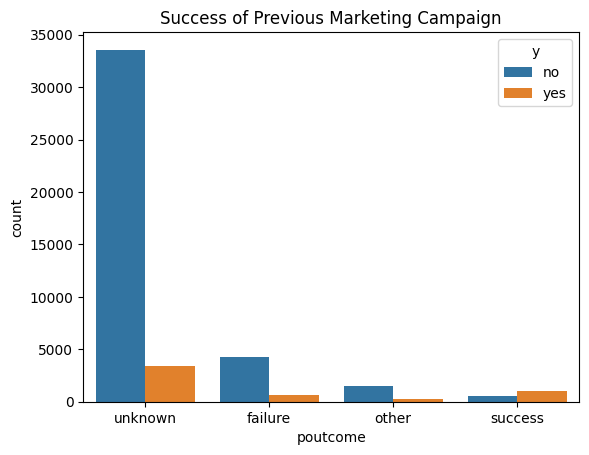

In [4]:
# Create age ranges
df['age_range'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])

# Table: Subscription status (y) by Age Range
age_y_table = pd.crosstab(df['age_range'], df['y'])
print(age_y_table)

# Table: Previous outcome (poutcome) by Marital Status
poutcome_marital_table = pd.crosstab(df['poutcome'], df['marital'])
print(poutcome_marital_table)

# Visual: Bar chart for poutcome
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='poutcome', hue='y', data=df)
plt.title('Success of Previous Marketing Campaign')
plt.show()

In [5]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [6]:
X = df.drop("y", axis=1)
y = df["y"]


In [7]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns


In [8]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [11]:
early_stopping_monitor = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)


In [12]:
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/Users/trimac/.virtualenvs/ist360/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping_monitor]
)


Epoch 1/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step - accuracy: 0.8873 - loss: 0.2980 - val_accuracy: 0.8985 - val_loss: 0.2253
Epoch 2/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.8957 - loss: 0.2382 - val_accuracy: 0.9028 - val_loss: 0.2164
Epoch 3/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 419us/step - accuracy: 0.8997 - loss: 0.2271 - val_accuracy: 0.9038 - val_loss: 0.2120
Epoch 4/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - accuracy: 0.8996 - loss: 0.2240 - val_accuracy: 0.9053 - val_loss: 0.2106
Epoch 5/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.9032 - loss: 0.2202 - val_accuracy: 0.9038 - val_loss: 0.2101
Epoch 6/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - accuracy: 0.9018 - loss: 0.2190 - val_accuracy: 0.9049 - val_loss: 0.2082
Epoch 7/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.9019 - loss: 0.2164 - val_accuracy: 0.9039 - val_loss: 0.2074
Epoch 8/200
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.9029 - loss: 0

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_classes))

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.9085 - loss: 0.2054
Test Accuracy: 0.9085480570793152
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step
[[7650  335]
 [ 492  566]]


print(classification_report(y_test, y_pred_classes))

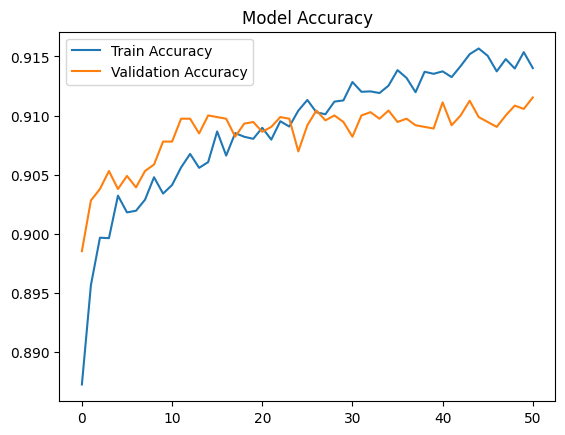

In [15]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()
